#Carregamento das bibliotecas

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
from yellowbrick.classifier import ConfusionMatrix

#Carregamento do Conjunto de dados

In [15]:
base = pd.read_csv('/content/insurance.csv')
base = base.drop(columns = ['Unnamed: 0'])
base.Accident.unique()


array(['Mild', nan, 'Moderate', 'Severe'], dtype=object)

In [16]:
base.head()

,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,DrivQuality,...,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,Poor,...,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
1,False,Senior,Prole,Cautious,Current,NaN,Football,NaN,Economy,Normal,...,City,True,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero
2,False,Senior,UpperMiddle,Psychopath,Current,NaN,Football,NaN,FamilySedan,Excellent,...,City,False,Thousand,Thousand,False,Thousand,Good,True,Thousand,One
3,False,Adolescent,Middle,Normal,Older,NaN,EggShell,NaN,Economy,Normal,...,Suburb,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Zero
4,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,Poor,...,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many


In [17]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   GoodStudent   20000 non-null  bool  
 1   Age           20000 non-null  object
 2   SocioEcon     20000 non-null  object
 3   RiskAversion  20000 non-null  object
 4   VehicleYear   20000 non-null  object
 5   ThisCarDam    5319 non-null   object
 6   RuggedAuto    20000 non-null  object
 7   Accident      5664 non-null   object
 8   MakeModel     20000 non-null  object
 9   DrivQuality   20000 non-null  object
 10  Mileage       20000 non-null  object
 11  Antilock      20000 non-null  bool  
 12  DrivingSkill  20000 non-null  object
 13  SeniorTrain   20000 non-null  bool  
 14  ThisCarCost   20000 non-null  object
 15  Theft         20000 non-null  bool  
 16  CarValue      20000 non-null  object
 17  HomeBase      20000 non-null  object
 18  AntiTheft     20000 non-null  bool  
 19  Prop

In [37]:
base['Accident'] = base['Accident'].fillna('unknown')

In [38]:
X = base.iloc[:,[0,1,2,3,4,5,6,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26]].values
y = base.iloc[:, 7].values


In [42]:
accident_counts = base['Accident'].value_counts()
accident_counts


,count
Accident,
unknown,14336
Severe,2322
Mild,1738
Moderate,1604


In [ ]:
labelencoder = LabelEncoder()
X[:,0] = labelencoder.fit_transform(X[:,0])
X[:,1] = labelencoder.fit_transform(X[:,1])
X[:,2] = labelencoder.fit_transform(X[:,2])
X[:,3] = labelencoder.fit_transform(X[:,3])
X[:,4] = labelencoder.fit_transform(X[:,4])
X[:,5] = labelencoder.fit_transform(X[:,5])
X[:,6] = labelencoder.fit_transform(X[:,6])
X[:,7] = labelencoder.fit_transform(X[:,7])
X[:,8] = labelencoder.fit_transform(X[:,8])
X[:,9] = labelencoder.fit_transform(X[:,9])
X[:,10] = labelencoder.fit_transform(X[:,10])
X[:,11] = labelencoder.fit_transform(X[:,11])
X[:,12] = labelencoder.fit_transform(X[:,12])
X[:,13] = labelencoder.fit_transform(X[:,13])
X[:,14] = labelencoder.fit_transform(X[:,14])
X[:,15] = labelencoder.fit_transform(X[:,15])
X[:,16] = labelencoder.fit_transform(X[:,16])
X[:,17] = labelencoder.fit_transform(X[:,17])
X[:,18] = labelencoder.fit_transform(X[:,18])
X[:,19] = labelencoder.fit_transform(X[:,19])
X[:,20] = labelencoder.fit_transform(X[:,20])
X[:,21] = labelencoder.fit_transform(X[:,21])
X[:,22] = labelencoder.fit_transform(X[:,22])
X[:,23] = labelencoder.fit_transform(X[:,23])
X[:,24] = labelencoder.fit_transform(X[:,24])
X[:,25] = labelencoder.fit_transform(X[:,25])


#Treinando o Modelo de Naive Bayes

In [21]:
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(X, y,
                                                                  test_size = 0.2,
                                                                  random_state = 42)

In [22]:
modelo = GaussianNB()
modelo.fit(X_treinamento, y_treinamento)

previsoes = modelo.predict(X_teste)



#Avaliando o Modelo de Naive Bayes

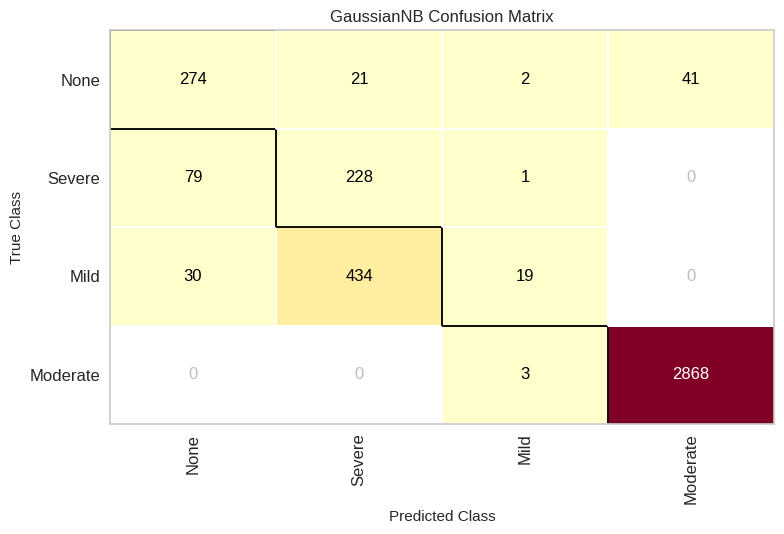

<Axes: title={'center': 'GaussianNB Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [23]:
confusao = ConfusionMatrix(modelo, classes=['None','Severe','Mild','Moderate'])
confusao.fit(X_treinamento, y_treinamento)
confusao.score(X_teste, y_teste)
confusao.poof()

In [43]:
precision_score(y_teste, previsoes, average='weighted')

0.8855598379107957

In [44]:
recall_score(y_teste, previsoes,average='weighted')

0.84725

In [45]:
f1_score(y_teste, previsoes, average='weighted')

0.8209742053190466

In [46]:
accuracy_score(y_teste, previsoes)

0.84725

#Treinando o  Modelo de àrvore de decisão

In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
import graphviz

In [60]:
for i in range(X.shape[1]):  # Iterate through all columns of X
    if isinstance(X[0, i], str):  # Check if the element is a string
        X[:, i] = labelencoder.fit_transform(X[:, i]) # Apply LabelEncoder if string

In [61]:
X_treinamento, X_teste, Y_treinamento, Y_teste = train_test_split(X, y,
                                                                  test_size = 0.2,
                                                                  random_state = 42)

In [62]:
Modelo1=DecisionTreeClassifier(criterion='entropy')
Modelo1.fit(X_treinamento, Y_treinamento)

DecisionTreeClassifier(criterion='entropy')

In [63]:
predict1=Modelo1.predict(X_teste)


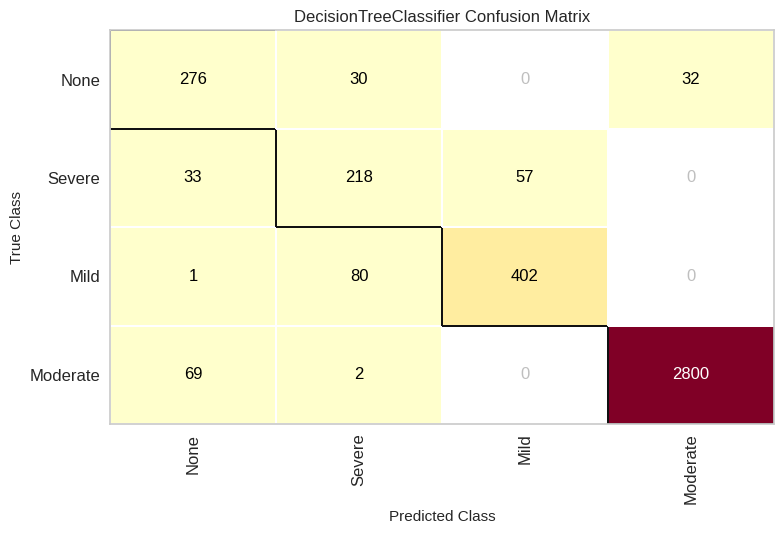

<Axes: title={'center': 'DecisionTreeClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [65]:
ConfusionMatrixtree = ConfusionMatrix(Modelo1, classes=['None','Severe','Mild','Moderate'])
ConfusionMatrixtree.fit(X_treinamento, Y_treinamento)
ConfusionMatrixtree.score(X_teste, Y_teste)
ConfusionMatrixtree.poof()

In [83]:
from sklearn.metrics import classification_report
metricas= classification_report(Y_teste, predict1,output_dict=True)